In [6]:
import keras
from sklearn.model_selection import train_test_split

# 1. Fashion MNIST 데이터셋 로드
(train_input, train_target), _ = keras.datasets.fashion_mnist.load_data()

# 2. 이미지 픽셀 값을 0~1 사이로 정규화
train_scaled = train_input / 255.0

# 3. 훈련 세트와 검증 세트를 8:2 비율로 분할
train_scaled, val_scaled, train_target, val_target = train_test_split(
    train_scaled, train_target, test_size=0.2, random_state=42
)

print("데이터 준비 완료!")
print(f"훈련 데이터 형태: {train_scaled.shape}")
print(f"검증 데이터 형태: {val_scaled.shape}")

데이터 준비 완료!
훈련 데이터 형태: (48000, 28, 28)
검증 데이터 형태: (12000, 28, 28)


▶ Dropout Rate 0.0 실험 학습 시작...
   [결과] Train Loss: 0.1746, Acc: 0.9371 | Val Loss: 0.3918, Acc: 0.8838

▶ Dropout Rate 0.2 실험 학습 시작...
   [결과] Train Loss: 0.2445, Acc: 0.9070 | Val Loss: 0.3281, Acc: 0.8878

▶ Dropout Rate 0.3 실험 학습 시작...
   [결과] Train Loss: 0.2762, Acc: 0.8961 | Val Loss: 0.3244, Acc: 0.8857

▶ Dropout Rate 0.5 실험 학습 시작...
   [결과] Train Loss: 0.3471, Acc: 0.8688 | Val Loss: 0.3430, Acc: 0.8748



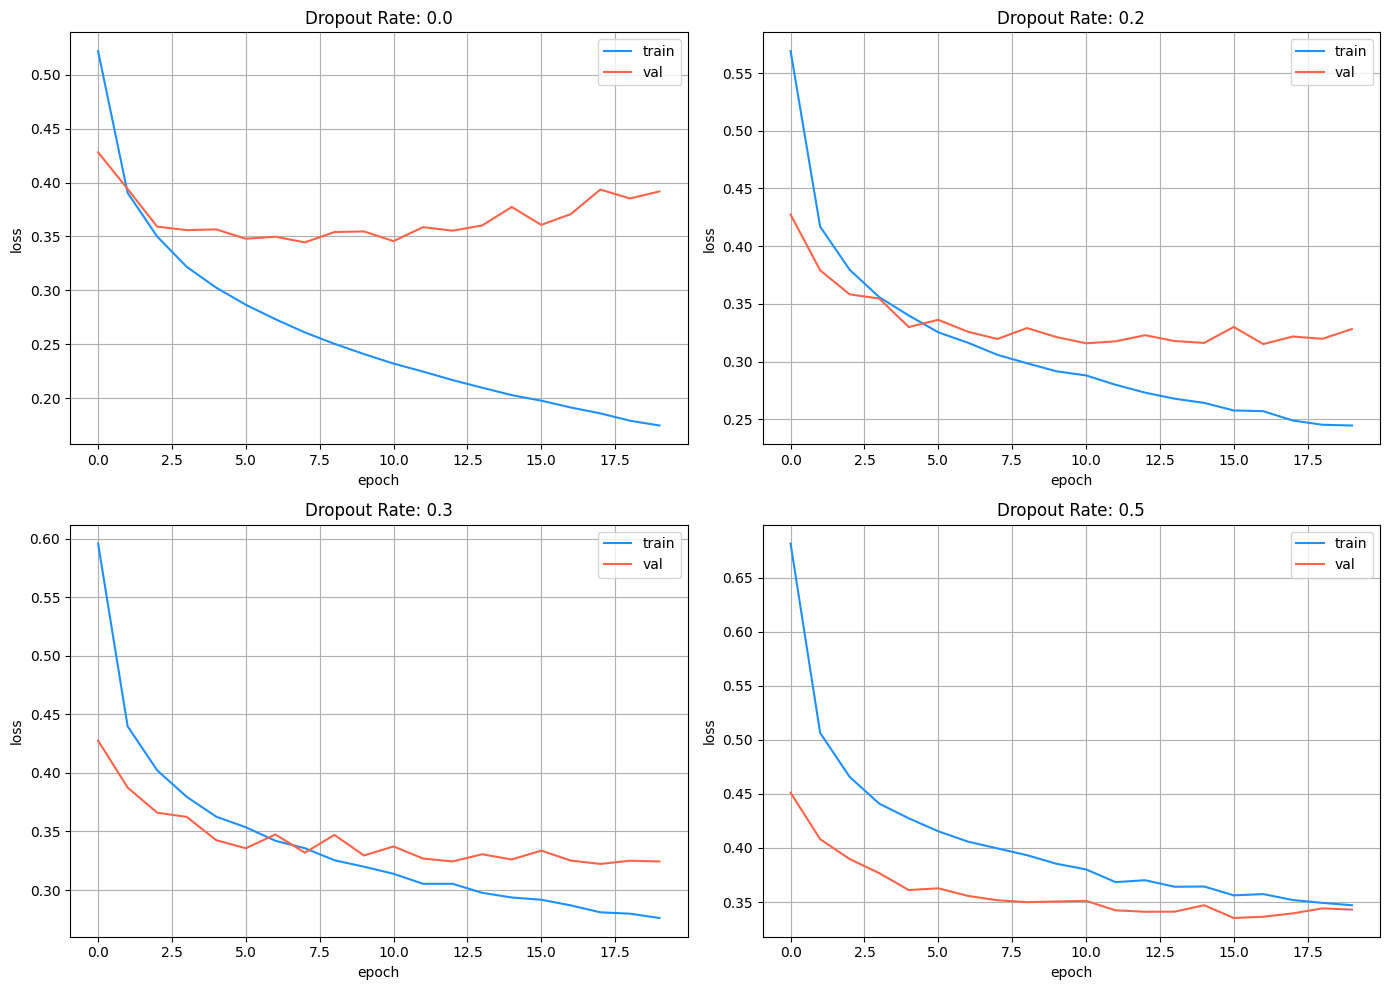

In [7]:
import matplotlib.pyplot as plt
import keras
import tensorflow as tf

# 실험할 드롭아웃 비율 리스트
dropout_rates = [0.0, 0.2, 0.3, 0.5]

# 시각화를 위한 그래프 설정 (2x2 서브플롯)
fig, axs = plt.subplots(2, 2, figsize=(14, 10))
axs = axs.ravel()  # 2차원 배열을 1차원으로 펼침

for idx, rate in enumerate(dropout_rates):
    # [보완] 이전 루프의 모델 가중치와 세션 그래프를 메모리에서 정리
    keras.backend.clear_session()
    
    # 1. 매 실험마다 동일한 조건 보장을 위해 난수 시드 재설정
    keras.utils.set_random_seed(42)
    tf.random.set_seed(42)
    tf.config.experimental.enable_op_determinism()
    
    # 2. 드롭아웃 비율을 반영한 모델 생성
    model = keras.Sequential()
    model.add(keras.layers.Input(shape=(28, 28)))
    model.add(keras.layers.Flatten())
    model.add(keras.layers.Dense(100, activation='relu'))
    
    # 드롭아웃 비율이 0보다 큰 경우에만 레이어 추가
    if rate > 0.0:
        model.add(keras.layers.Dropout(rate))
        
    model.add(keras.layers.Dense(10, activation='softmax'))
    
    # 3. 모델 컴파일
    model.compile(
        optimizer='adam', 
        loss='sparse_categorical_crossentropy', 
        metrics=['accuracy']
    )
    
    # 4. 모델 학습 (조기 종료 없이 20 에포크 고정)
    print(f"▶ Dropout Rate {rate} 실험 학습 시작...") 
    
    history = model.fit(
        train_scaled, train_target, 
        epochs=20, 
        verbose=0,  # 로그 생략
        validation_data=(val_scaled, val_target)
    )
    
    # 최종 에포크 결과 추출 및 출력
    final_train_loss = history.history['loss'][-1]
    final_val_loss = history.history['val_loss'][-1]
    final_train_acc = history.history['accuracy'][-1]
    final_val_acc = history.history['val_accuracy'][-1]
    
    print(f"   [결과] Train Loss: {final_train_loss:.4f}, Acc: {final_train_acc:.4f} | "
          f"Val Loss: {final_val_loss:.4f}, Acc: {final_val_acc:.4f}\n")
    
    # 5. 각 실험별 손실 곡선 그리기
    axs[idx].plot(history.history['loss'], label='train', color='dodgerblue')
    axs[idx].plot(history.history['val_loss'], label='val', color='tomato')
    axs[idx].set_title(f'Dropout Rate: {rate}')
    axs[idx].set_xlabel('epoch')
    axs[idx].set_ylabel('loss')
    axs[idx].legend()
    axs[idx].grid(True)

plt.tight_layout()
plt.show()